# Loading the Dataset

In [1]:
import pandas as pd
import numpy as np

file_path = "Electric_Vehicle_Population_Data.csv"
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nSample Data:\n")
print(df.head())

print("\nMissing Values per Column:\n")
print(df.isnull().sum())

Dataset Shape: (232230, 17)

Column Names:
 ['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Base MSRP', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract']

Sample Data:

   VIN (1-10)    County      City State  Postal Code  Model Year    Make  \
0  2T3YL4DV0E      King  Bellevue    WA      98005.0        2014  TOYOTA   
1  5YJ3E1EB6K      King   Bothell    WA      98011.0        2019   TESLA   
2  5UX43EU02S  Thurston   Olympia    WA      98502.0        2025     BMW   
3  JTMAB3FV5R  Thurston   Olympia    WA      98513.0        2024  TOYOTA   
4  5YJYGDEE8M    Yakima     Selah    WA      98942.0        2021   TESLA   

        Model                   Electric Vehicle Type  \
0        RAV4          Battery Electric Vehicle (BEV)   
1     MODEL 3          Battery Electric Vehicle (BEV)   
2          X5

# Data Cleaning

In [2]:
critical_columns = ['City', 'State', 'Postal Code', 'Electric Vehicle Type', 'Model', 'Make', 'Electric Range']
df_clean = df.dropna(subset=critical_columns)

df_clean['Base MSRP'] = df_clean['Base MSRP'].fillna(0)
df_clean = df_clean.dropna(subset=['Vehicle Location'])
df_clean = df_clean.reset_index(drop=True)
print("Cleaned Dataset Shape:", df_clean.shape)
print("\nRemaining Missing Values:\n")
print(df_clean.isnull().sum())

df.to_csv ("Cleaned_Electric_Vehicle_Population_Data.csv", index=False)

<ipython-input-2-a4d6b9eb55a9>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Base MSRP'] = df_clean['Base MSRP'].fillna(0)


Cleaned Dataset Shape: (232192, 17)

Remaining Missing Values:

VIN (1-10)                                             0
County                                                 0
City                                                   0
State                                                  0
Postal Code                                            0
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base MSRP                                              0
Legislative District                                 477
DOL Vehicle ID                                         0
Vehicle Location                                       0
Electric Utility                                       0
2020 Census Tract       

# EV Count by City

<ipython-input-3-37dc4a9cde14>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette="coolwarm")


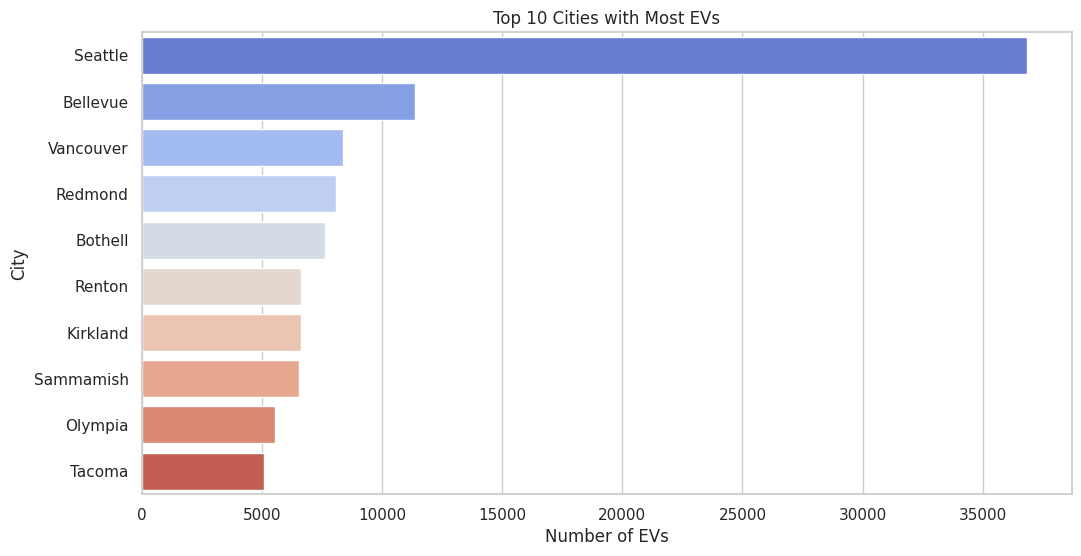

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
top_cities = df_clean['City'].value_counts().head(10)
top_states = df_clean['State'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_cities.values, y=top_cities.index, palette="coolwarm")
plt.title('Top 10 Cities with Most EVs')
plt.xlabel('Number of EVs')
plt.ylabel('City')
plt.show()

# Pie Chart (Distribution of Battery Electric Vehicles (BEV) vs PHEV)

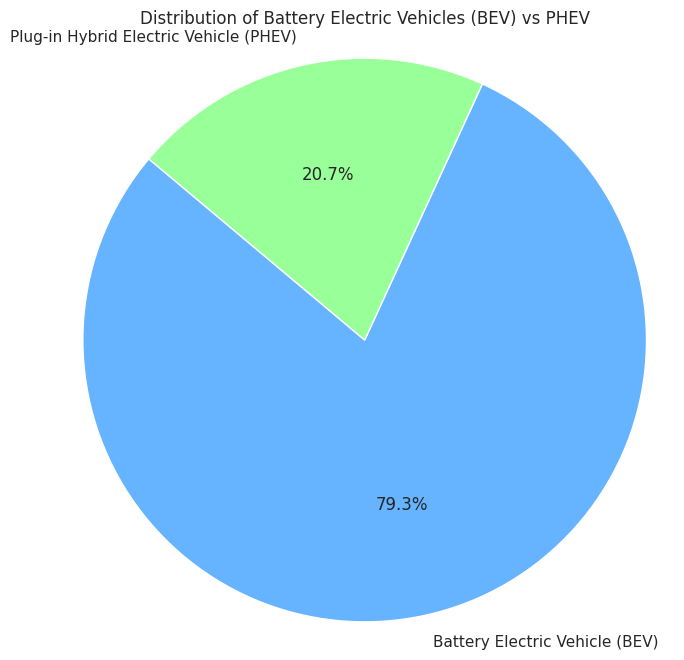

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df_clean = pd.read_csv('Cleaned_Electric_Vehicle_Population_Data.csv')
ev_type_counts = df_clean['Electric Vehicle Type'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    ev_type_counts.values,
    labels=ev_type_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#66b3ff', '#99ff99']
)
plt.title('Distribution of Battery Electric Vehicles (BEV) vs PHEV')
plt.axis('equal')
plt.show()


# Factors Making Location Ideal

<ipython-input-5-cca25ef7051a>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Electric Vehicle Type', data=df_clean, palette='Set2')


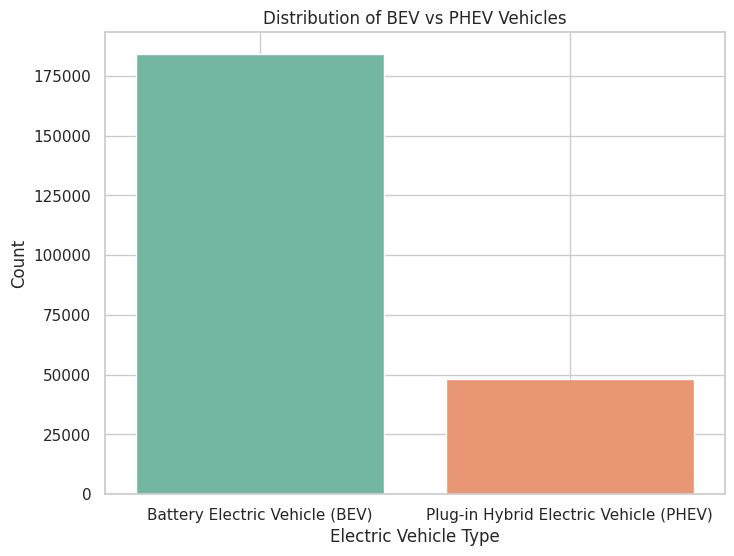

In [5]:
df_clean['Electric Vehicle Type'] = df_clean['Electric Vehicle Type'].str.strip()

plt.figure(figsize=(8,6))
sns.countplot(x='Electric Vehicle Type', data=df_clean, palette='Set2')
plt.title('Distribution of BEV vs PHEV Vehicles')
plt.xlabel('Electric Vehicle Type')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# Aggregate EV Counts by Postal Code

In [6]:
df_clean = df_clean.dropna(subset=['Postal Code'])
df_clean['Postal Code'] = df_clean['Postal Code'].astype(int)

<ipython-input-6-460efa1d51b1>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Postal Code'] = df_clean['Postal Code'].astype(int)


In [7]:
df_clean['Postal Code'] = df_clean['Postal Code'].astype(int)
ev_by_zip = df_clean.groupby('Postal Code').size().reset_index(name='EV Count')

location_data = df_clean[['Postal Code', 'City', 'State', 'Vehicle Location']].drop_duplicates()
merged = pd.merge(ev_by_zip, location_data, on='Postal Code', how='left')
merged[['Longitude', 'Latitude']] = merged['Vehicle Location'].str.extract(r'POINT \((-?\d+\.\d+)\s(-?\d+\.\d+)\)')

merged.dropna(subset=['Latitude', 'Longitude'], inplace=True)
merged['Latitude'] = merged['Latitude'].astype(float)
merged['Longitude'] = merged['Longitude'].astype(float)

merged.head()

<ipython-input-7-543a7dc1eb07>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Postal Code'] = df_clean['Postal Code'].astype(int)


,Postal Code,EV Count,City,State,Vehicle Location,Longitude,Latitude
0,1731,2,Hanscom Afb,MA,POINT (-71.28309 42.45982),-71.28309,42.45982
1,1749,1,Hudson,MA,POINT (-71.56452 42.39139),-71.56452,42.39139
2,1890,1,Winchester,MA,POINT (-71.14567 42.44958),-71.14567,42.44958
3,2108,1,Boston,MA,POINT (-71.05972 42.35905),-71.05972,42.35905
4,2110,1,Boston,MA,POINT (-71.05456 42.35578),-71.05456,42.35578


# Clustering Analysis to Identify High-Demand Areas(K-Means)

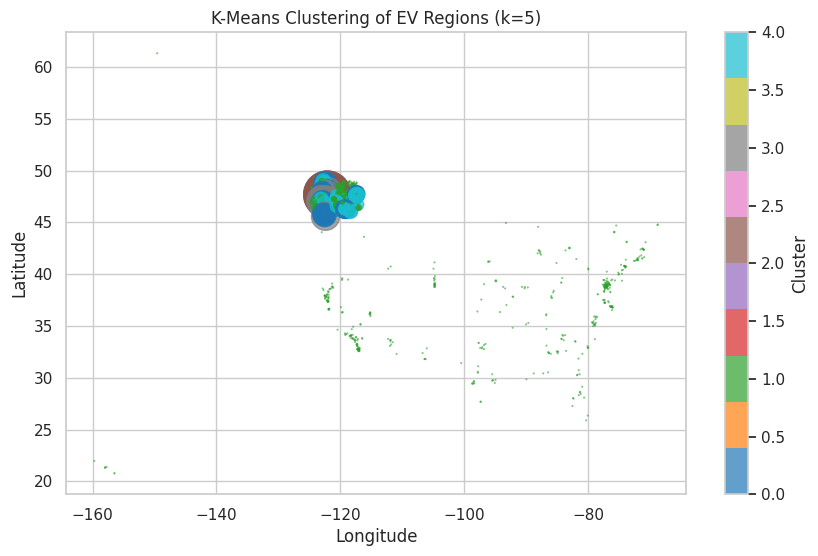

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = merged[['Latitude', 'Longitude', 'EV Count']]

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
merged['Cluster'] = kmeans.fit_predict(X)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(merged['Longitude'], merged['Latitude'], c=merged['Cluster'], cmap='tab10', s=merged['EV Count']*0.2, alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.title(f"K-Means Clustering of EV Regions (k={k})")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

# Geographic Visualization Using Folium Map

In [9]:
import folium
from folium.plugins import MarkerCluster

map_center = [47.5, -122.2]
m = folium.Map(location=map_center, zoom_start=8)

marker_cluster = MarkerCluster().add_to(m)

colors = ['red', 'blue', 'green', 'orange', 'purple', 'darkred', 'cadetblue']

for _, row in merged.iterrows():
    popup_text = f"Postal Code: {row['Postal Code']}<br>EV Count: {row['EV Count']}<br>Cluster: {row['Cluster']}"
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5 + (row['EV Count'] / 1000),  # Bubble size by EV count
        color=colors[int(row['Cluster']) % len(colors)],
        fill=True,
        fill_opacity=0.6,
        popup=popup_text
    ).add_to(marker_cluster)

m

In [10]:
top_by_cluster = merged.groupby('Cluster').apply(lambda x: x.nlargest(3, 'EV Count')).reset_index(drop=True)
top_by_cluster[['Postal Code', 'City', 'EV Count', 'Cluster']]

<ipython-input-10-b0b705aa1ea9>:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_by_cluster = merged.groupby('Cluster').apply(lambda x: x.nlargest(3, 'EV Count')).reset_index(drop=True)


,Postal Code,City,EV Count,Cluster
0,98031,Kent,1382,0
1,98031,Renton,1382,0
2,98682,Vancouver,1382,0
3,98403,Tacoma,212,1
4,98360,Orting,211,1
5,99202,Spokane,210,1
6,98052,Redmond,5730,2
7,98052,Woodinville,5730,2
8,98052,Kirkland,5730,2
9,98103,Seattle,2688,3


In [11]:
m.save('ev_cluster_map.html')

In [12]:
top_by_cluster.to_csv('recommended_ev_station_zones.csv', index=False)

In [13]:
top_by_cluster[['Postal Code', 'City', 'EV Count', 'Cluster']].to_csv('ev_station_priority_list.csv', index=False)

# Simple Predictive Modeling - Time Series Forecasting

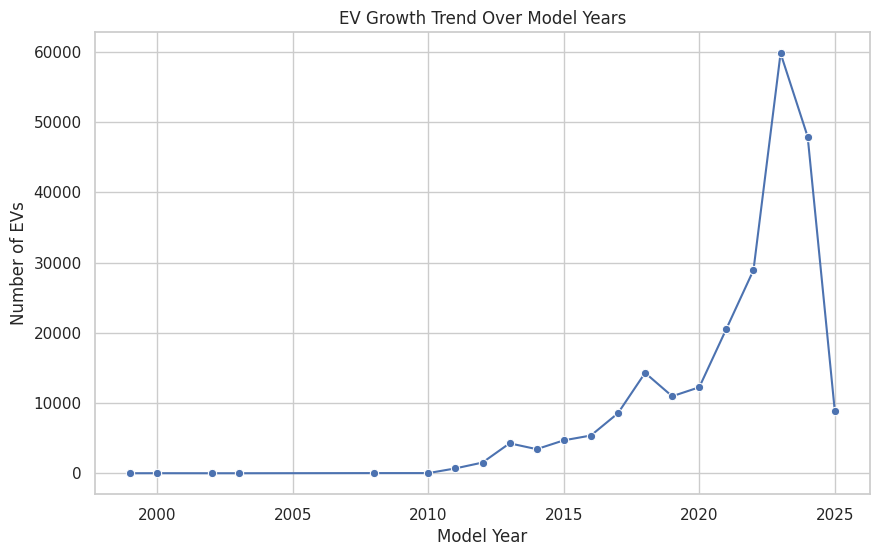

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

model_year_df = df_clean.dropna(subset=['Model Year'])
ev_yearly = model_year_df.groupby('Model Year').size().reset_index(name='EV Count')

plt.figure(figsize=(10,6))
sns.lineplot(x='Model Year', y='EV Count', data=ev_yearly, marker='o')
plt.title('EV Growth Trend Over Model Years')
plt.xlabel('Model Year')
plt.ylabel('Number of EVs')
plt.grid(True)
plt.show()

# Predict Future High-Demand Areas

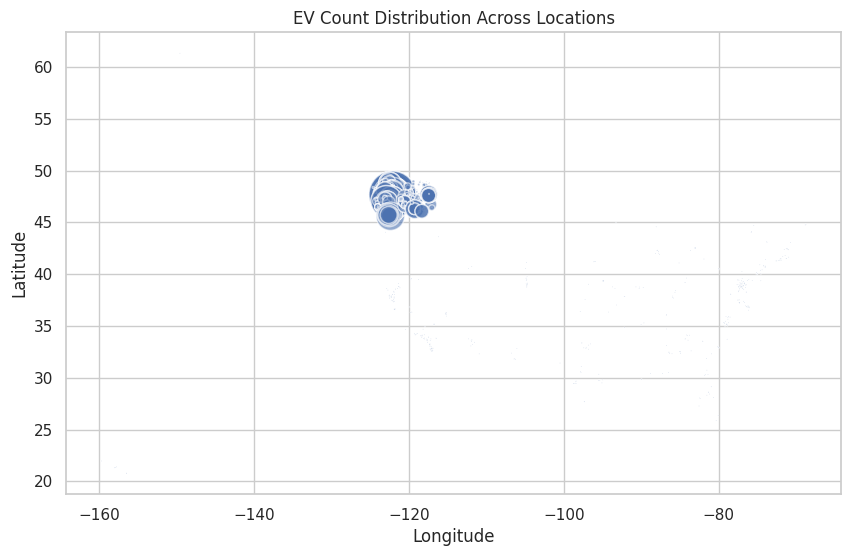

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(merged['Longitude'], merged['Latitude'],
            s=merged['EV Count']*0.2,
            alpha=0.6,
            edgecolors='w')
plt.title('EV Count Distribution Across Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

# **Forecasting EV Registration Growth using ML Models**

## Linear Regression

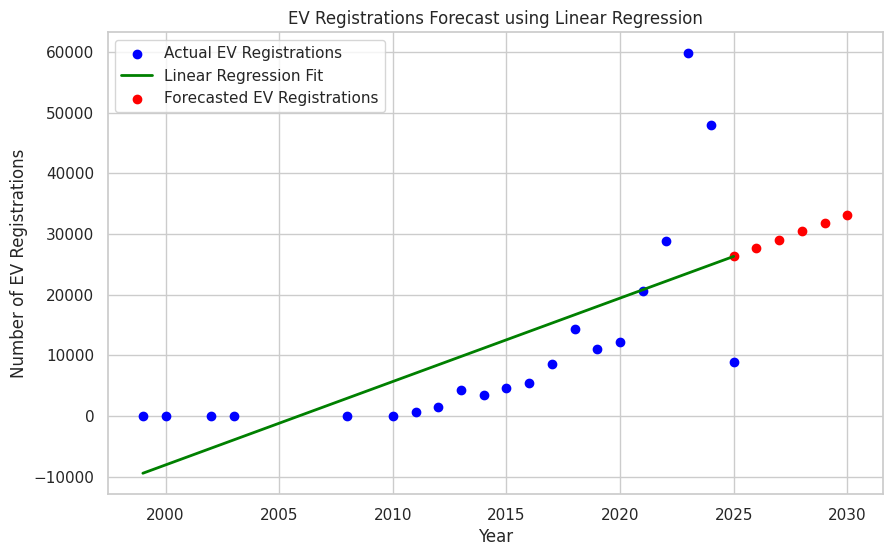

R-squared (R²): 0.451
Mean Absolute Error (MAE): 8831.03
Mean Squared Error (MSE): 137944942.92
Root Mean Squared Error (RMSE): 11745.00


In [16]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Read the dataset
df = pd.read_csv('Electric_Vehicle_Population_Data.csv')

# Data Cleaning
df = df.dropna(subset=['Model Year'])  # Drop missing model years

# Aggregate EV count by Model Year
ev_yearly = df.groupby('Model Year').size().reset_index(name='EV_Count')

# Define features and target
X = ev_yearly[['Model Year']]  # Independent variable
y = ev_yearly['EV_Count']      # Dependent variable

# Train Linear Regression Model
model = LinearRegression()
model.fit(X, y)

# Predict on existing data
y_pred = model.predict(X)

# Predict for future years till 2030
future_years = pd.DataFrame({'Model Year': np.arange(2025, 2031)})
future_pred = model.predict(future_years)

# Plot Actual Data + Model Fit + Forecast
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual EV Registrations')
plt.plot(X, y_pred, color='green', linewidth=2, label='Linear Regression Fit')
plt.scatter(future_years, future_pred, color='red', label='Forecasted EV Registrations')
plt.title('EV Registrations Forecast using Linear Regression')
plt.xlabel('Year')
plt.ylabel('Number of EV Registrations')
plt.legend()
plt.grid(True)
plt.show()

# Predict the training set itself
y_train_pred = model.predict(X)

# Calculate metrics
r2 = r2_score(y, y_train_pred)
mae = mean_absolute_error(y, y_train_pred)
mse = mean_squared_error(y, y_train_pred)
rmse = np.sqrt(mse)

# Print metrics
print(f"R-squared (R²): {r2:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


## Random Forest Regressor

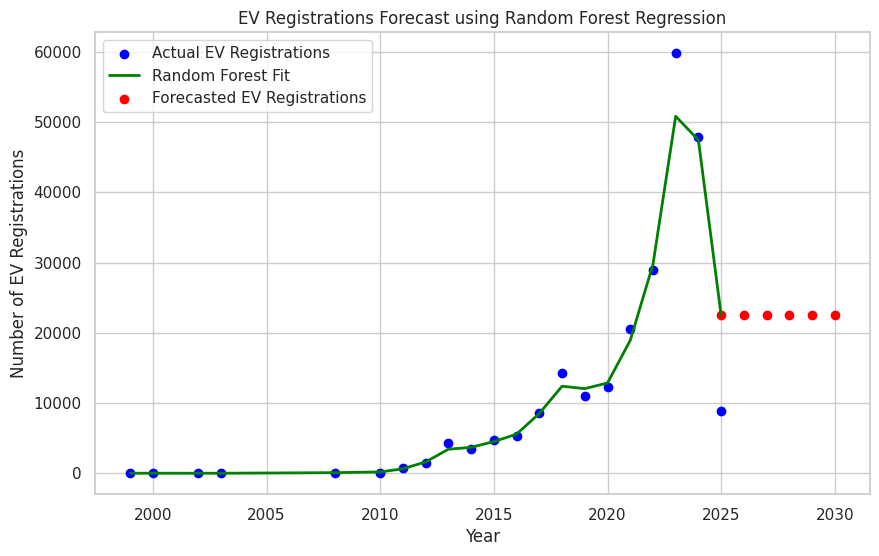

R-squared (R²): 0.948
Mean Absolute Error (MAE): 1475.28
Mean Squared Error (MSE): 13084203.96
Root Mean Squared Error (RMSE): 3617.21


In [17]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Read the dataset
df = pd.read_csv('Electric_Vehicle_Population_Data.csv')

# Data Cleaning
df = df.dropna(subset=['Model Year'])

# Aggregate EV count by Model Year
ev_yearly = df.groupby('Model Year').size().reset_index(name='EV_Count')

# Features and target
X = ev_yearly[['Model Year']]  # Independent variable
y = ev_yearly['EV_Count']      # Dependent variable

# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Predict on training data
y_rf_pred = rf_model.predict(X)

# Predict future EV registrations for 2025–2030
future_years = pd.DataFrame({'Model Year': np.arange(2025, 2031)})
future_rf_pred = rf_model.predict(future_years)

# Plot Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual EV Registrations')
plt.plot(X, y_rf_pred, color='green', linewidth=2, label='Random Forest Fit')
plt.scatter(future_years, future_rf_pred, color='red', label='Forecasted EV Registrations')
plt.title('EV Registrations Forecast using Random Forest Regression')
plt.xlabel('Year')
plt.ylabel('Number of EV Registrations')
plt.legend()
plt.grid(True)
plt.show()

# Evaluation metrics
r2 = r2_score(y, y_rf_pred)
mae = mean_absolute_error(y, y_rf_pred)
mse = mean_squared_error(y, y_rf_pred)
rmse = np.sqrt(mse)

print(f"R-squared (R²): {r2:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
